In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, cdist

In [2]:
df = pd.read_csv('new-thyroid.csv')

In [3]:
df.head()

,107,10.1,2.2,0.9,2.7,1
0,113,9.9,3.1,2.0,5.9,1
1,127,12.9,2.4,1.4,0.6,1
2,109,5.3,1.6,1.4,1.5,1
3,105,7.3,1.5,1.5,-0.1,1
4,105,6.1,2.1,1.4,7.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   107     214 non-null    int64  
 1   10.1    214 non-null    float64
 2   2.2     214 non-null    float64
 3   0.9     214 non-null    float64
 4   2.7     214 non-null    float64
 5   1       214 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 10.2 KB


In [5]:
X = df.iloc[:, 1:5].values
y_true = df.iloc[:, 5].values

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# 2. Melakukan Clustering untuk Setiap Metode Linkage
linkage_methods = ['single', 'complete', 'average', 'centroid']

# Dictionary untuk menyimpan hasil dari setiap metode.
results = {}

--- Memproses Metode Linkage: Single ---
Dendrogram disimpan sebagai 'dendrogram_single.png'
Varians (mirip WCSS): 723.59
Akurasi: 0.7056
Rasio Kesalahan: 0.2944

--- Memproses Metode Linkage: Complete ---
Dendrogram disimpan sebagai 'dendrogram_complete.png'
Varians (mirip WCSS): 471.29
Akurasi: 0.8364
Rasio Kesalahan: 0.1636

--- Memproses Metode Linkage: Average ---
Dendrogram disimpan sebagai 'dendrogram_average.png'
Varians (mirip WCSS): 539.08
Akurasi: 0.7336
Rasio Kesalahan: 0.2664

--- Memproses Metode Linkage: Centroid ---
Dendrogram disimpan sebagai 'dendrogram_centroid.png'
Varians (mirip WCSS): 516.75
Akurasi: 0.7430
Rasio Kesalahan: 0.2570



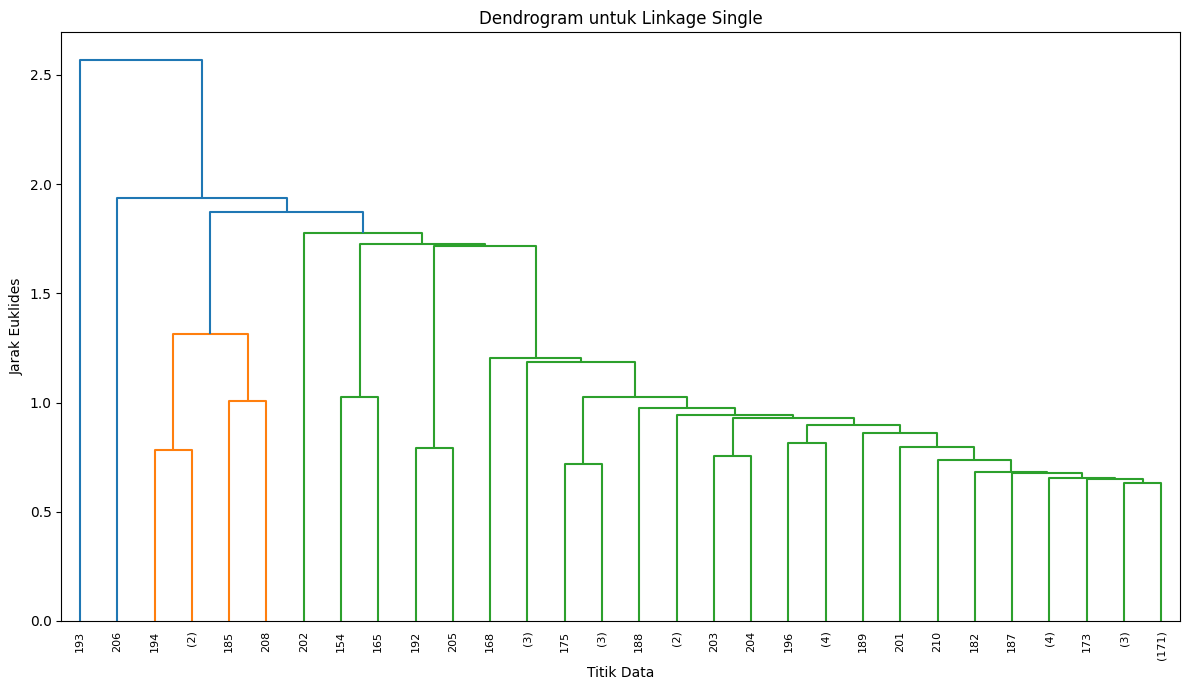

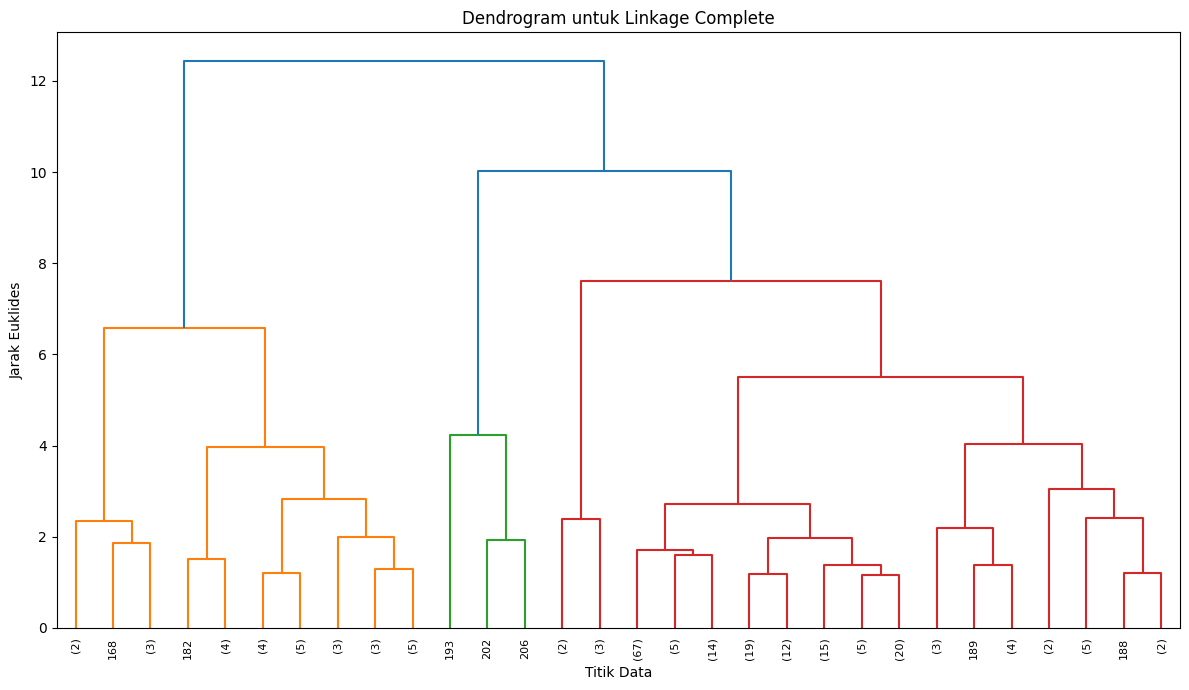

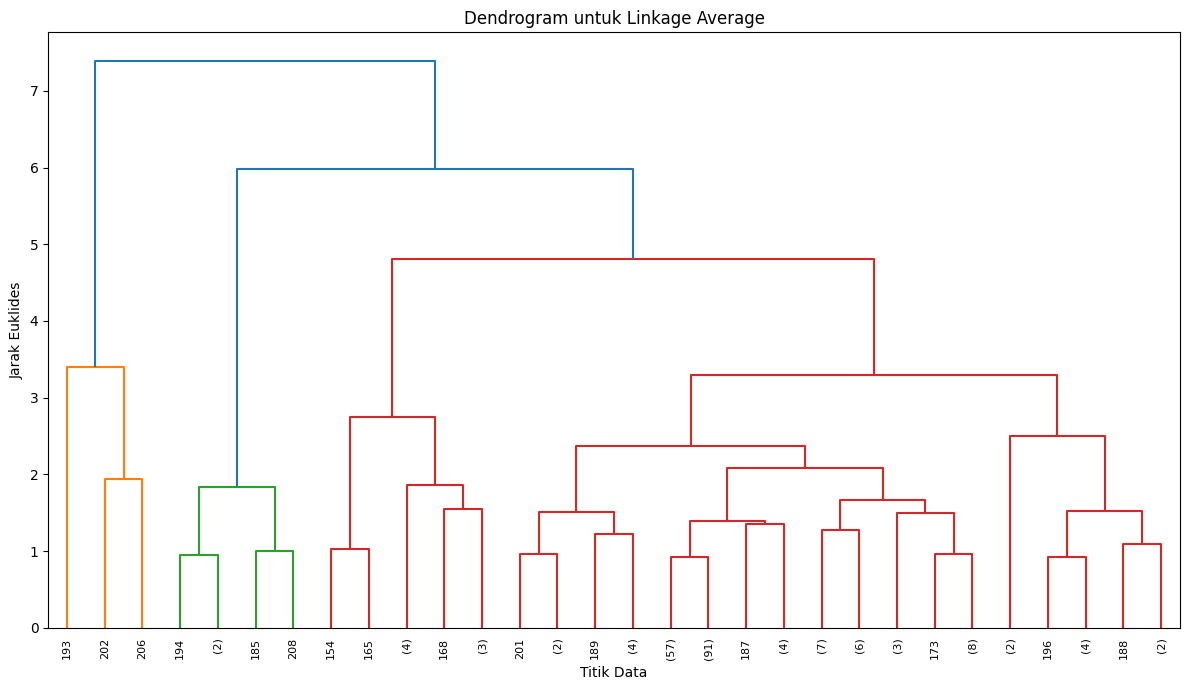

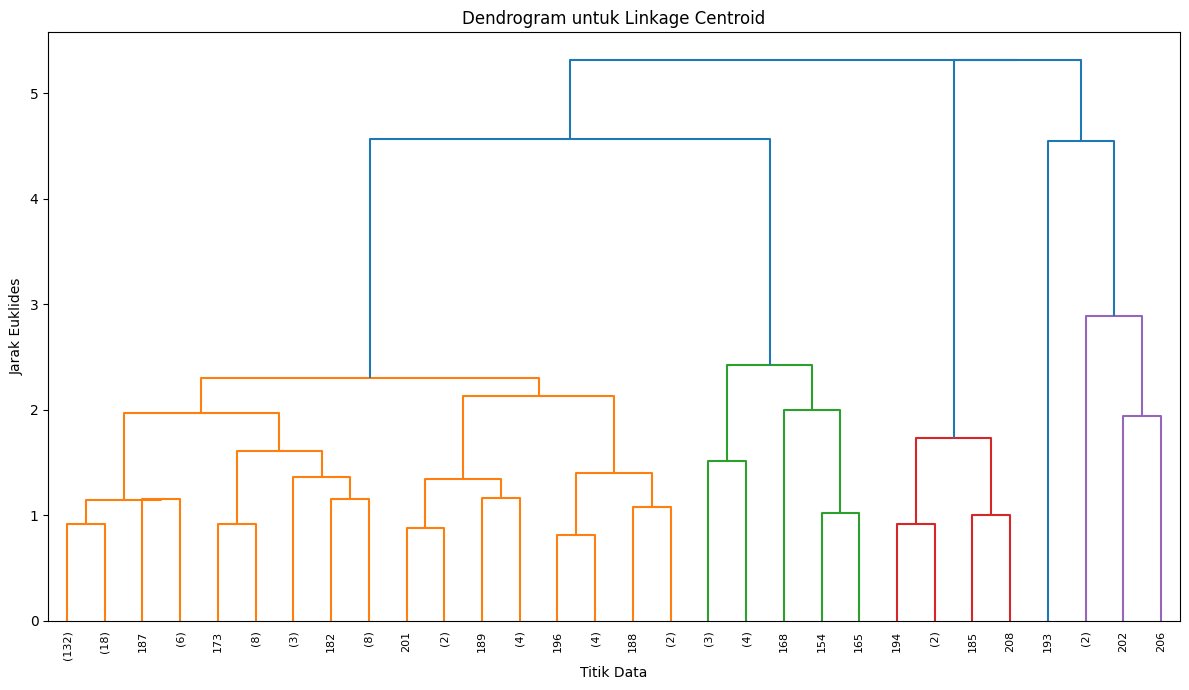

In [8]:
# Looping melalui setiap metode linkage.
for method in linkage_methods:
    print(f"--- Memproses Metode Linkage: {method.capitalize()} ---")

    # Melakukan hierarchical clustering.
    Z = linkage(X_scaled, method=method, metric='euclidean')

    # --- 3. Visualisasi (Membuat Dendrogram) ---
    plt.figure(figsize=(12, 7))
    plt.title(f'Dendrogram untuk Linkage {method.capitalize()}')
    plt.xlabel('Titik Data')
    plt.ylabel('Jarak Euklides')
    
    # Membuat dendrogram. 'truncate_mode' digunakan untuk menyederhanakan
    dendrogram(Z, leaf_rotation=90., leaf_font_size=8.,
               truncate_mode='lastp', p=30) # 'p=30' menunjukkan 30 cluster gabungan terakhir.
    
    plt.tight_layout()
    dendrogram_filename = f'dendrogram_{method}.png'
    plt.savefig(dendrogram_filename)
    print(f"Dendrogram disimpan sebagai '{dendrogram_filename}'")

    # --- 4. Menghitung Metrik Evaluasi ---
    
    # Memotong dendrogram untuk mendapatkan 3 cluster.
    cluster_labels = fcluster(Z, t=3, criterion='maxclust')

    # Menghitung metrik varians (mirip dengan WCSS pada K-Means).
    total_wcss = 0
    for i in np.unique(cluster_labels):
        cluster_points = X_scaled[cluster_labels == i]
        centroid = cluster_points.mean(axis=0).reshape(1, -1)
        # Menghitung jumlah kuadrat jarak dari setiap titik ke centroid clusternya.
        wcss = np.sum(cdist(cluster_points, centroid, 'sqeuclidean'))
        total_wcss += wcss
    
    print(f"Varians (mirip WCSS): {total_wcss:.2f}")

    # Menghitung Rasio Kesalahan.
    df_result = pd.DataFrame({'cluster': cluster_labels, 'true_label': y_true})
    contingency_matrix = pd.crosstab(df_result['cluster'], df_result['true_label'])
    
    # Menemukan pemetaan terbaik dengan mencari label asli yang paling sering muncul di setiap cluster.
    mapping = contingency_matrix.idxmax(axis=1)
    
    # Menerapkan pemetaan untuk mendapatkan label prediksi.
    predicted_labels = pd.Series(cluster_labels).map(mapping)
    
    # Menghitung akurasi dan rasio kesalahan.
    accuracy = accuracy_score(y_true, predicted_labels)
    error_ratio = 1 - accuracy
    
    print(f"Akurasi: {accuracy:.4f}")
    print(f"Rasio Kesalahan: {error_ratio:.4f}\n")

    # Menyimpan hasil ke dalam dictionary.
    results[method] = {
        'variance': total_wcss,
        'accuracy': accuracy,
        'error_ratio': error_ratio,
    }

In [9]:
# 5. Mencetak Ringkasan Hasil Akhir
print("\n--- Ringkasan Hasil Hierarchical Clustering ---")
summary_df = pd.DataFrame({
    'Linkage': [method.capitalize() for method in results.keys()],
    'Variance (WCSS-like)': [f"{res['variance']:.2f}" for res in results.values()],
    'Accuracy': [f"{res['accuracy']:.4f}" for res in results.values()],
    'Error Ratio': [f"{res['error_ratio']:.4f}" for res in results.values()]
})
# Mencetak tabel ringkasan tanpa indeks baris.
print(summary_df.to_string(index=False))


--- Ringkasan Hasil Hierarchical Clustering ---
 Linkage Variance (WCSS-like) Accuracy Error Ratio
  Single               723.59   0.7056      0.2944
Complete               471.29   0.8364      0.1636
 Average               539.08   0.7336      0.2664
Centroid               516.75   0.7430      0.2570
